Repeat QA of regridding after the refactor: verify that we can reproduce Ecology's DOmin values on the grid.

Ecology provides DOmin values for all of their runs on their webmap on the 303(d) grid. We also have their model output files. So if we are regridding correctly, we should be able to reproduce their DOmin numbers.

Because Ecology rounds their DO values, and because regridding can be complex with different numbers of TCEs mapping to grid rectangles, we test all the cells to look for any discrepancies.

In [1]:
case_file = '/gscratch/ssmc/USRS/PSI/Ben/projects/Ecy25_analysis/SSM_config_ecy25.yaml'
run_dir = 'wqm_baseline'
ecology_data = 'min_exist'

import os
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np

sys.path.append('../../py_scripts')
import ssm_utils

In [2]:
ssm, case = ssm_utils.read_case(case_file)

Inferring case name to be ecy25


In [3]:
process_netcdf_output_wc = Path(ssm['paths']['processed_output']) / case / 'DOXG_303d' / run_dir / 'wc' / 'daily_min_DOXG_wc.nc'
ds_process = xr.open_dataset(process_netcdf_output_wc, engine='netcdf4')
ds_process

<xarray.Dataset> Size: 237MB
Dimensions:            (day: 360, siglay: 10, id_303d: 8224)
Coordinates:
  * day                (day) datetime64[ns] 3kB 2014-01-06 ... 2014-12-31
  * siglay             (siglay) float64 80B 0.032 0.057 0.075 ... 0.138 0.146
  * id_303d            (id_303d) <U9 296kB '47122A9I7' ... '48124E8B0'
Data variables:
    DOXG_daily_min_wc  (day, siglay, id_303d) float64 237MB ...
Attributes:
    version:  2

In [4]:
gdf_303d = gpd.read_file(ssm['paths']['303d']['shapefile']
    ).set_index('id_303d').rename(columns={
        'area_m2': 'Area_m2'
    })

In [5]:
MinDO_annual_303d = ds_process['DOXG_daily_min_wc'].min(dim=('day','siglay'))

In [6]:
domin_df = pd.DataFrame({
    'ecology': gdf_303d[ecology_data],
    'ours': MinDO_annual_303d
}, index=gdf_303d.index)
domin_df.head()

,ecology,ours
id_303d,,
47122A9I7,6.7,6.704266
47122A9I8,6.9,6.862889
47122A9J6,6.5,6.494305
47122A9J7,6.6,6.551112
47122B5H9,5.3,5.268556


In [7]:
failed_matches = domin_df.loc[domin_df['ours'].round(1) != domin_df['ecology']]
print(f'{len(failed_matches)} failed matches out of {len(domin_df)} grid cells')
failed_matches

2 failed matches out of 8224 grid cells


,ecology,ours
id_303d,,
47122C7J1,4.3,4.249979
47123D1H2,1.2,1.250030


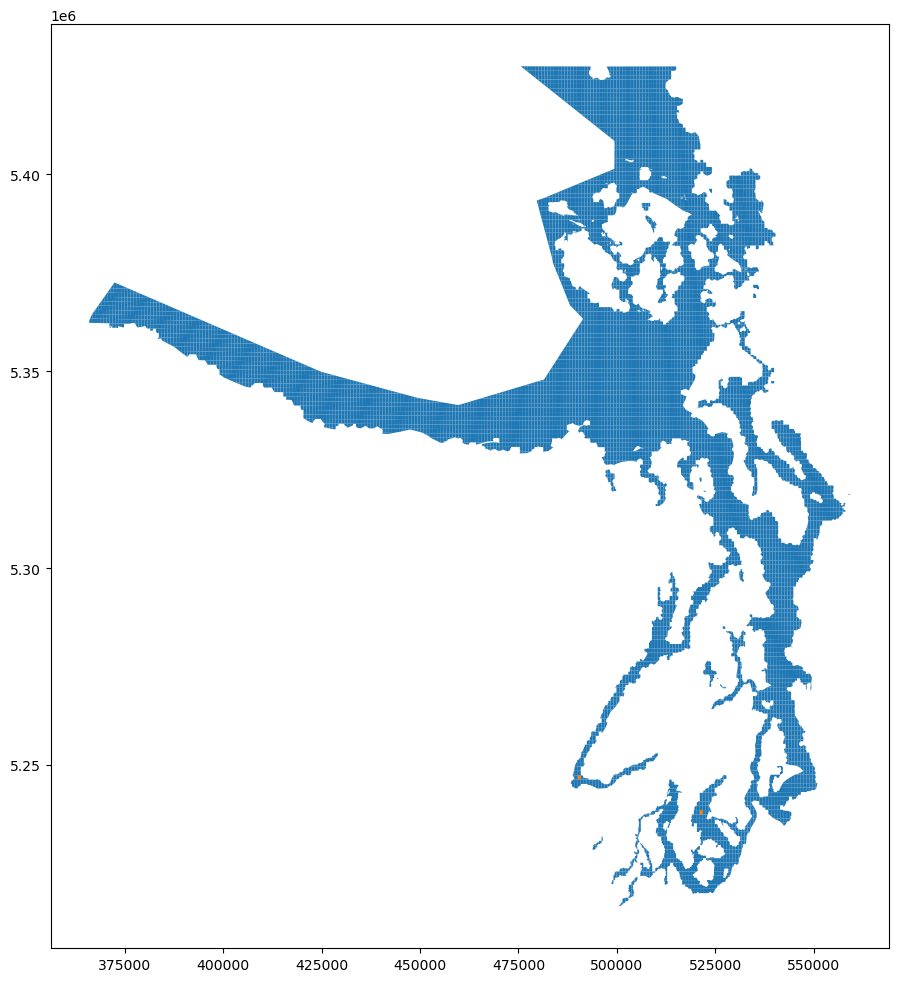

In [8]:
ax = gdf_303d.plot(figsize=(12,12))
gdf_303d.loc[
    failed_matches.loc[~pd.isna(failed_matches['ours'])].index
].plot(ax=ax, color='tab:orange');

[Text(0.5, 0, 'Ecology'), Text(0, 0.5, 'Our regridding')]

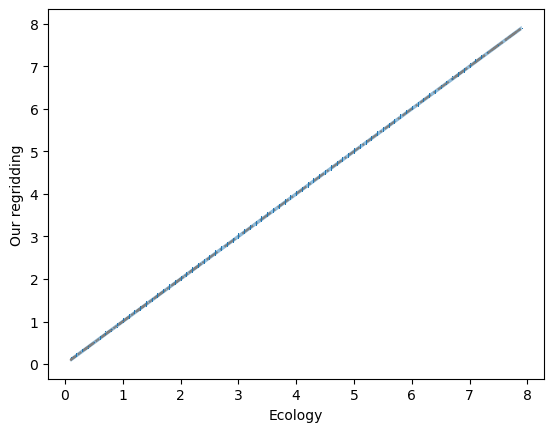

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(domin_df['ecology'], domin_df['ecology'], '-.', color='tab:gray')
ax.fill_between(domin_df['ecology'].sort_values(), domin_df['ecology'].sort_values() - 0.05, domin_df['ecology'].sort_values() + 0.05, alpha=0.5)
ax.plot(domin_df['ecology'], domin_df['ours'], ',')
ax.set(xlabel='Ecology', ylabel='Our regridding')

In [10]:
np.sqrt(((domin_df['ours'] - domin_df['ecology']) ** 2).mean())

np.float64(0.028704363969781575)